In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

df = pd.read_csv("yelp_subset.csv")
df.head()

,review_id,user_id,business_id,date,text,useful,funny,cool,name,neighborhood,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,categories
0,zsbVXbCsycrTWkVlsKsVOg,u3NDqJr25UwYeXZypxJcqw,xBkXnzbctPGWG86L27GNFQ,2015-01-03,We brought our Doxie to Dr. Scholten for serio...,0,0,1,"""Hopi Animal Hospital""",NaN,"""5533 E Bell Rd, Ste 101""",Scottsdale,AZ,85254,33.639916,-111.961780,4.5,30,1,Pet Services;Pet Sitting;Pets;Veterinarians
1,d3iCvvJsJZs4U-ZFfq_pSA,DxHP0hTWS9Jpd-xSVCMYAg,JDjOobEd_Tm6Z06YRmWkbg,2008-05-13,"First, I'm a regular here. Sunday afternoons a...",5,3,5,"""Charlie's""",NaN,"""727 W Camelback Rd""",Phoenix,AZ,85013,33.508967,-112.083610,3.0,158,1,Bars;Nightlife;Dance Clubs;Gay Bars
2,yTS2FOyhmRHgwAXSG8muiQ,-aYO8Ga4U5hrwxV7y1IaiA,qiRyyRWt6jmAxcoVW0-WHA,2015-08-02,"Best AYCE in Mississauga. For an AYCE, their s...",6,0,1,"""Heart Sushi""",East Credit,"""815 Britannia Road W, Unit 2""",Mississauga,ON,L5V 2X8,43.610533,-79.698421,3.5,278,1,Chinese;Japanese;Buffets;Restaurants;Sushi Bars
3,W1PG83hPCogZdLlstltWZw,EJLsnsI53YKBHq9te2KSiQ,t67GMPZ0cv_ItKlID-JFiQ,2013-04-10,"Love it! It's a nice quick, inexpensive & tast...",0,1,0,"""Banzo""",NaN,"""2105 Sherman Ave""",Madison,WI,53704,43.101672,-89.364595,4.5,286,1,Food;Mediterranean;Food Trucks;Restaurants
4,Q8IuYiUzeK-Uc8mK-luL3w,gknq0IAq9jaSlotJ465FGw,6P-JmU0VW-qhYq7It1wowg,2014-11-10,Dont eat here! Doesnt even taste like pho here...,0,0,0,"""Pho 68""",NaN,"""2025 N Dobson Rd""",Chandler,AZ,85224,33.336151,-111.874338,3.5,77,0,Vietnamese;Restaurants


## Word cloud for reviews where "cleaning" appears in categories

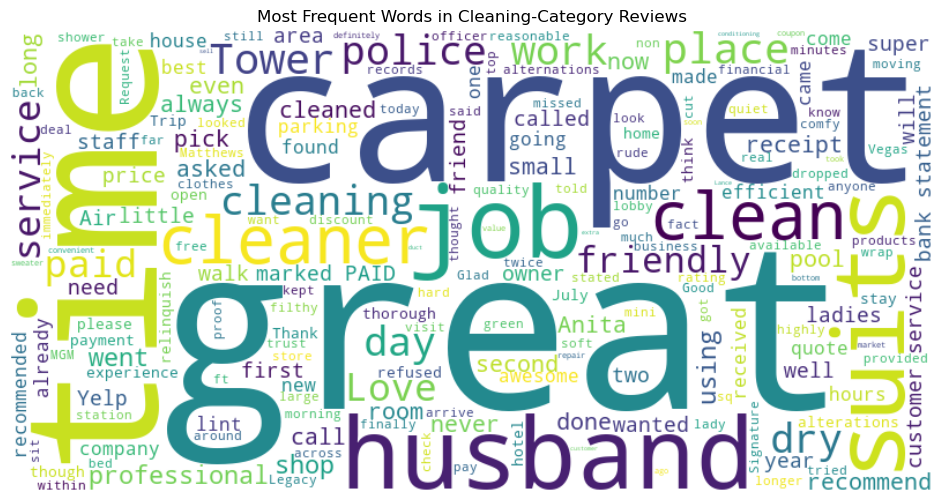

In [5]:
# Filter rows where "cleaning" appears in the categories column
cleaning_df = df[df['categories'].str.contains("cleaning", case=False, na=False)]

# Combine all review text into one big string
cleaning_text = " ".join(cleaning_df['text'].astype(str))

# Generate the word cloud
wc = WordCloud(width=800, height=400, background_color="white").generate(cleaning_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Cleaning-Category Reviews")
plt.show()

## Word cloud for 5-star reviews

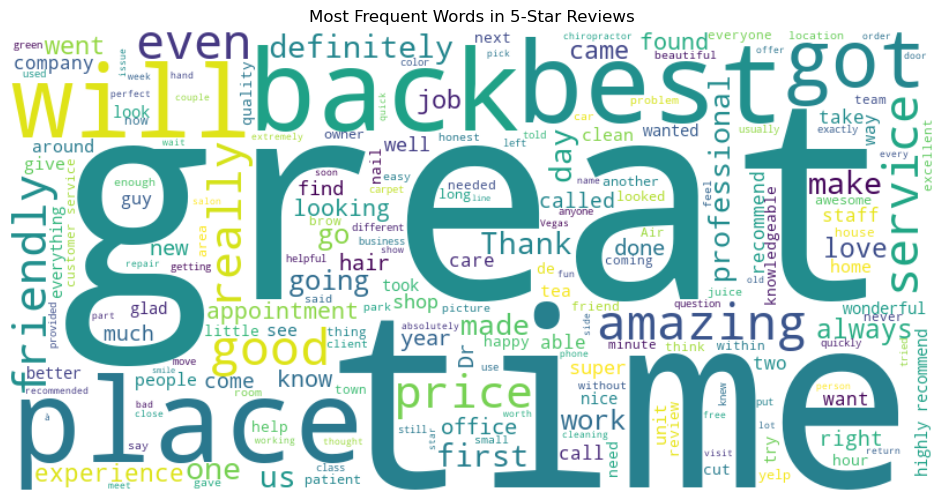

In [6]:
# Filter for 5-star reviews
five_star_df = df[df['stars'] == 5]

# Combine all review text into one big string
five_star_text = " ".join(five_star_df['text'].astype(str))

# Generate the word cloud
wc2 = WordCloud(width=800, height=400, background_color="white").generate(five_star_text)

plt.figure(figsize=(12,6))
plt.imshow(wc2, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in 5-Star Reviews")
plt.show()

## Sentiment of different keywords

In [7]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

# Function to compute sentiment for reviews containing a keyword
def keyword_sentiment(keyword):
    subset = df[df['text'].str.contains(keyword, case=False, na=False)]
    subset['sentiment'] = subset['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
    return subset['sentiment'].mean()

# Try different keywords
keywords = ["amazing", "terrible", "friendly", "rude", "clean", "slow"]

for word in keywords:
    print(word, keyword_sentiment(word))

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Haley\AppData\Roaming\nltk_data...
C:\Users\Haley\AppData\Local\Temp\ipykernel_17864\674802893.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['sentiment'] = subset['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
C:\Users\Haley\AppData\Local\Temp\ipykernel_17864\674802893.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['sentiment'] = subset['text'].apply(lambda x: sia.polarity_scores(x)['compound'])

amazing 0.8949250000000001
terrible 0.027080645161290298


C:\Users\Haley\AppData\Local\Temp\ipykernel_17864\674802893.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['sentiment'] = subset['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
C:\Users\Haley\AppData\Local\Temp\ipykernel_17864\674802893.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['sentiment'] = subset['text'].apply(lambda x: sia.polarity_scores(x)['compound'])


friendly 0.8659530201342281
rude -0.1877921568627451
clean 0.7123721590909091
slow 0.4676785714285714


C:\Users\Haley\AppData\Local\Temp\ipykernel_17864\674802893.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['sentiment'] = subset['text'].apply(lambda x: sia.polarity_scores(x)['compound'])
C:\Users\Haley\AppData\Local\Temp\ipykernel_17864\674802893.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['sentiment'] = subset['text'].apply(lambda x: sia.polarity_scores(x)['compound'])


I tested several keywords using VADER sentiment analysis. The word "amazing' produced a very high average sentiment score (0.89), indicating that reviews containing this word are strongly positive. In contrast, the word "rude" produced a negative average sentiment score (-0.18), showing that reviews using this term tend to express dissatisfaction. These results demonstrate how individual keyowrds can signal the emotional tone of a review.

## Max Review Length by Star Rating

In [8]:
# Add a column for review length
df['review_length'] = df['text'].str.len()

# Group by star rating and compute the max length
max_lengths = df.groupby('stars')['review_length'].max()

max_lengths

stars
1.0    2591
1.5    2138
2.0    2033
2.5    4223
3.0    3732
3.5    3669
4.0    4010
4.5    3200
5.0    3863
Name: review_length, dtype: int64

<Axes: xlabel='stars'>

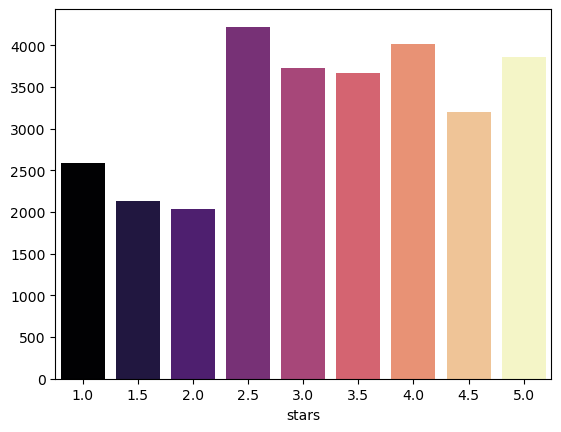

In [10]:
sns.barplot(
    x=max_lengths.index,
    y=max_lengths.values,
    hue=max_lengths.index,   # assign hue to satisfy the new rule
    palette="magma",
    legend=False             # hide the legend since hue = x
)

When comparing mean review length to max review length, the patterns differ. The mean review length tends to increase for lower star ratings, suggesting that customers write more when they are dissatisfied. However, the maximum review length varies unpredictably across star ratings because a single unusually long review can occur in any category. This makes the max statistic less stable and less reflective of typical review behavior compared to the mean.